# Distribution Sanity Checks — v2

Refactor of the original sanity check addressing four thesis-advisor notes:

1. **Data-justified thresholds** — read from `_threshold_justifications.csv`
   produced by the Threshold Calibration notebook. No more hardcoded magic
   numbers.
2. **Per-resource tier classification** — each of Billex / Morphology /
   Parcor gets its own tier (`good` / `needs_attention` / `broken` /
   `not_applicable`). A separate `overall_tier` is derived from these.
3. **Source-aware violations** — dictionaries whose source PDF has no
   example sentences get `parcor_tier = not_applicable` instead of being
   punished for an empty Parcor. Detected heuristically from the
   preprocessing file's `contoh_kalimat` column.
4. **Fix-to-rule mapping** — each fix notebook is explicitly associated
   with the rules it targets. The post-fix comparison distinguishes
   expected improvements (rules with fix scripts) from unexpected ones
   (rules without).

## New outputs (in `../evaluation/sanity_v2/`)

- `_per_dict_metrics.csv` — same wide format as v1, but with `billex_tier`,
  `morph_tier`, `parcor_tier`, `overall_tier` columns
- `_quality_tiers.csv` — per-dict tier assignments (pre-fix and post-fix)
- `_catastrophic_failures.csv` — dicts with 0-row resources despite the
  source presumably containing entries; each with a suspected root cause
- `_fix_impact_report.csv` — for each fix script, the rules it targeted and
  the actual pre/post violation counts per rule
- `_source_profiles.csv` — source-feature detection results per dict
- Plots: tier breakdown (pre vs post), remaining violations, per-resource
  tier distributions

## 1. Imports & paths

In [2]:
import re
import ast
from pathlib import Path
from collections import Counter
from typing import Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from _common import parse_dict_id, load_direction_lookup, direction_for

DIRS = {
    "prep":         Path("../Ekstraksi/6. Pemecahan Definisi Lema"), 
    "billex":       Path("../Ekstraksi/9. Bilingual Lexicon"),
    "morph":        Path("../Ekstraksi/10. Morphology"),
    "parcor":       Path("../Ekstraksi/11. Parallel Corpus"),
    "billex_fixed": Path("../Ekstraksi/9. Bilingual Lexicon - Fixed"),
    "morph_fixed":  Path("../Ekstraksi/10. Morphology - Fixed"),
    "parcor_fixed": Path("../Ekstraksi/11. Parallel Corpus - Fixed"),
}

CALIBRATION = Path("../evaluation/calibration/_threshold_justifications.csv")
DST_DIR = Path("../evaluation/sanity_v2")
DST_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_GOOD_DICTS = ["10", "35", "68", "91"]

for name, d in DIRS.items():
    print(f"  {name:<14}  exists={d.exists()}  {d}")
print(f"\n  calibration    exists={CALIBRATION.exists()}  {CALIBRATION}")
print(f"\nWriting to: {DST_DIR.resolve()}")

assert CALIBRATION.exists(), (
    f"Run Threshold Calibration.ipynb first to produce {CALIBRATION}"
)

  prep            exists=True  ..\Ekstraksi\6. Pemecahan Definisi Lema
  billex          exists=True  ..\Ekstraksi\9. Bilingual Lexicon
  morph           exists=True  ..\Ekstraksi\10. Morphology
  parcor          exists=True  ..\Ekstraksi\11. Parallel Corpus
  billex_fixed    exists=True  ..\Ekstraksi\9. Bilingual Lexicon - Fixed
  morph_fixed     exists=True  ..\Ekstraksi\10. Morphology - Fixed
  parcor_fixed    exists=True  ..\Ekstraksi\11. Parallel Corpus - Fixed

  calibration    exists=True  ..\evaluation\calibration\_threshold_justifications.csv

Writing to: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKamus\evaluation\sanity_v2


## 2. Load calibrated thresholds

Instead of hardcoded values, thresholds come from the calibration notebook.
Rules are grouped by resource so each resource can be tiered independently.

In [3]:
thresholds_df = pd.read_csv(CALIBRATION)
print(f"Loaded {len(thresholds_df)} calibrated thresholds")

# Group rules by resource (billex/morph/parcor)
RESOURCE_RULES = {
    "billex": [],
    "morph":  [],
    "parcor": [],
}
for _, row in thresholds_df.iterrows():
    rule = row["rule_name"]
    for resource in RESOURCE_RULES:
        if rule.startswith(resource + "_"):
            RESOURCE_RULES[resource].append({
                "rule": rule,
                "metric": row["metric_column"],
                "threshold": row["threshold"],
                "direction": row["direction"],
            })
            break

for r, rules in RESOURCE_RULES.items():
    print(f"  {r}: {len(rules)} rules")

Loaded 9 calibrated thresholds
  billex: 3 rules
  morph: 2 rules
  parcor: 4 rules


## 3. Fix-to-rule mapping

Explicitly documents which fix notebook targets which rule. Used in §9 for
the diagnostic impact report.

In [4]:
FIX_TO_RULES = {
    "fix_billex_headword_batch":    ["billex_high_multiword_ind"],
    "fix_morphology_split_batch":   ["morph_low_tag_coverage"],
    "fix_parcor_batch":             ["parcor_high_placeholders"],
}

# Invert the mapping for per-rule lookup
RULE_TO_FIX = {rule: fix for fix, rules in FIX_TO_RULES.items() for rule in rules}

print("Fix → Rules mapping:")
for fix, rules in FIX_TO_RULES.items():
    print(f"  {fix}:")
    for r in rules:
        print(f"    - {r}")

Fix → Rules mapping:
  fix_billex_headword_batch:
    - billex_high_multiword_ind
  fix_morphology_split_batch:
    - morph_low_tag_coverage
  fix_parcor_batch:
    - parcor_high_placeholders


## 4. Source feature detection

For each dict, check the preprocessing file to see if the source has
example sentences (`contoh_kalimat` column populated for a meaningful
fraction of rows). If not, `parcor_tier` gets `not_applicable` instead of
being flagged for empty output.

Morphology and POS source detection is NOT handled here (colleague's scope).

In [5]:
PARCOR_SOURCE_THRESHOLD = 0.10  # need >=10% of prep rows to have contoh_kalimat


def detect_parcor_source(dict_id: str) -> dict:
    """
    Returns {has_examples: bool, example_rate: float, prep_rows: int}.
    Falls back to has_examples=True if the prep file isn't found (don't
    mark a dict not_applicable just because we couldn't check).
    """
    prep_files = list(DIRS["prep"].glob(f"{dict_id}_*.csv")) if DIRS["prep"].exists() else []
    if not prep_files:
        return {"has_examples": True, "example_rate": float("nan"), "prep_rows": 0}

    try:
        prep = pd.read_csv(prep_files[0])
    except Exception:
        return {"has_examples": True, "example_rate": float("nan"), "prep_rows": 0}

    if "contoh_kalimat" not in prep.columns or len(prep) == 0:
        return {"has_examples": True, "example_rate": float("nan"), "prep_rows": len(prep)}

    has_content = prep["contoh_kalimat"].notna() & (
        prep["contoh_kalimat"].astype(str).str.strip() != ""
    )
    rate = has_content.mean()
    return {
        "has_examples": bool(rate >= PARCOR_SOURCE_THRESHOLD),
        "example_rate": round(float(rate), 4),
        "prep_rows": len(prep),
    }

## 5. Per-resource metric collectors

Copied from v1 with the NaN-safety fixes we added earlier. These compute
metrics only — tier assignment happens separately using the calibrated
thresholds.

In [6]:
def parse_list_cell(s):
    if isinstance(s, list): return s
    try:
        v = ast.literal_eval(s) if isinstance(s, str) else []
        return v if isinstance(v, list) else []
    except Exception:
        return []


def collect_billex_metrics(path: Path, direction: Optional[int]) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0 or "kata_asal" not in df.columns or "kata_tujuan" not in df.columns:
        return {"billex_rows": n}

    if direction == 1:
        ind_col, reg_col = "kata_asal", "kata_tujuan"
    else:
        ind_col, reg_col = "kata_tujuan", "kata_asal"

    def first_of(v):
        if not isinstance(v, str):
            return ""
        lst = parse_list_cell(v)
        if lst:
            first = lst[0]
            return str(first).strip() if first is not None else ""
        return v.strip()

    if direction == 1:
        ind_series = df[ind_col].fillna("").astype(str).str.strip()
        reg_series = df[reg_col].apply(first_of)
    else:
        ind_series = df[ind_col].apply(first_of)
        reg_series = df[reg_col].fillna("").astype(str).str.strip()

    null_rate = df[[ind_col, reg_col]].isna().any(axis=1).mean()
    multiword_ind_rate = ind_series.str.contains(r"\s", na=False, regex=True).mean()

    return {
        "billex_rows": n,
        "billex_null_rate": round(float(null_rate), 4),
        "billex_multiword_ind_rate": round(float(multiword_ind_rate), 4),
    }


def collect_morph_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"morph_rows": 0}

    if "tag" in df.columns:
        tag_col = df["tag"].fillna("").astype(str).str.strip()
        tag_coverage = (tag_col != "") & (tag_col.str.lower() != "nan")
        tag_coverage_rate = tag_coverage.mean()
    else:
        tag_coverage_rate = 0.0

    return {
        "morph_rows": n,
        "morph_tag_coverage": round(float(tag_coverage_rate), 4),
    }


def collect_parcor_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"parcor_rows": 0}

    if "kalimat_asal" not in df.columns or "kalimat_tujuan" not in df.columns:
        return {"parcor_rows": n, "parcor_null_rate": 1.0}

    asal = df["kalimat_asal"].fillna("").astype(str)
    tujuan = df["kalimat_tujuan"].fillna("").astype(str)

    null_rate = df[["kalimat_asal", "kalimat_tujuan"]].isna().any(axis=1).mean()

    placeholder_re = re.compile(r"(?:^|\s)(--|-)(?=\s|$|[.,;:!?])")
    ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()

    len_asal = asal.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    len_tujuan = tujuan.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    short_rate = ((len_asal <= 2) | (len_tujuan <= 2)).mean()

    return {
        "parcor_rows": n,
        "parcor_null_rate": round(float(null_rate), 4),
        "parcor_placeholder_rate": round(float(ph_rate), 4),
        "parcor_short_rate": round(float(short_rate), 4),
    }

## 6. Per-resource tier assignment

Given metrics and the calibrated thresholds, assign a tier to each
resource. Violations are collected per-resource, then:
- 0 violations → `good`
- 1 violation → `needs_attention`
- 2+ violations → `broken`

The `not_applicable` tier is set externally (only for Parcor based on
source detection).

In [7]:
def check_violations_for_resource(metrics: dict, resource: str) -> list:
    """Return list of violated rule names for this resource."""
    violated = []
    for rule_info in RESOURCE_RULES[resource]:
        metric_val = metrics.get(rule_info["metric"])
        if metric_val is None or (isinstance(metric_val, float) and np.isnan(metric_val)):
            continue
        if rule_info["direction"] == "high" and metric_val > rule_info["threshold"]:
            violated.append(rule_info["rule"])
        elif rule_info["direction"] == "low" and metric_val < rule_info["threshold"]:
            violated.append(rule_info["rule"])
    return violated


def assign_tier_from_violations(n_violations: int) -> str:
    if n_violations == 0:
        return "good"
    if n_violations == 1:
        return "needs_attention"
    return "broken"


def assign_overall_tier(resource_tiers: dict) -> str:
    """
    Derive overall_tier from the three resource tiers.
    - Ignore any resource marked 'not_applicable'.
    - If any applicable resource is 'broken' → overall is 'broken'.
    - If any applicable resource is 'needs_attention' → overall is 'needs_attention'.
    - Else → 'good'.
    """
    applicable = [t for t in resource_tiers.values() if t != "not_applicable"]
    if not applicable:
        return "not_applicable"
    if "broken" in applicable:
        return "broken"
    if "needs_attention" in applicable:
        return "needs_attention"
    return "good"

## 7. Process every dictionary

In [8]:
direction_lookup = load_direction_lookup()

billex_files = sorted(DIRS["billex"].glob("*_Billex.csv")) if DIRS["billex"].exists() else []
dict_ids = sorted({parse_dict_id(p.name) for p in billex_files} - {None}, key=lambda s: int(s))
print(f"Found {len(dict_ids)} dictionaries")


def find_csv(dir_: Path, dict_id: str, suffix: str) -> Optional[Path]:
    if not dir_.exists():
        return None
    matches = list(dir_.glob(f"{dict_id}_{suffix}.csv"))
    return matches[0] if matches else None


all_metrics = []
for dict_id in dict_ids:
    m = {
        "dict_id": dict_id,
        "direction": direction_for(dict_id, direction_lookup),
    }
    m["direction_known"] = m["direction"] is not None

    # Source detection (Parcor only)
    src = detect_parcor_source(dict_id)
    m["parcor_has_examples_in_source"] = src["has_examples"]
    m["parcor_source_example_rate"]    = src["example_rate"]
    m["prep_rows"]                     = src["prep_rows"]

    # Metrics — original resources
    for resource, suffix, collector in [
        ("billex", "Billex", lambda p: collect_billex_metrics(p, m["direction"] or 1)),
        ("morph",  "Morphology", collect_morph_metrics),
        ("parcor", "Parcor", collect_parcor_metrics),
    ]:
        p = find_csv(DIRS[resource], dict_id, suffix)
        if p:
            m.update(collector(p))

    # Metrics — fixed versions (suffix with "_fixed")
    for resource, suffix, collector in [
        ("billex_fixed", "Billex", lambda p: collect_billex_metrics(p, m["direction"] or 1)),
        ("morph_fixed",  "Morphology", collect_morph_metrics),
        ("parcor_fixed", "Parcor", collect_parcor_metrics),
    ]:
        p = find_csv(DIRS[resource], dict_id, suffix)
        if p:
            fixed_metrics = collector(p)
            prefix = resource.replace("_fixed", "_fixed_").replace("fixed_fixed", "fixed")
            # e.g. billex_rows -> billex_fixed_rows
            for k, v in fixed_metrics.items():
                new_key = k.replace(
                    resource.split("_")[0] + "_",
                    resource.split("_")[0] + "_fixed_",
                    1,
                )
                m[new_key] = v

    # Per-resource tier — PRE-FIX
    for resource in ["billex", "morph", "parcor"]:
        violations = check_violations_for_resource(m, resource)
        m[f"{resource}_violations_prefix"] = ";".join(violations)
        m[f"{resource}_tier_prefix"] = assign_tier_from_violations(len(violations))

    # Override parcor tier for dicts whose source has no examples
    if not m.get("parcor_has_examples_in_source", True):
        m["parcor_tier_prefix"] = "not_applicable"
        m["parcor_violations_prefix"] = ""

    m["overall_tier_prefix"] = assign_overall_tier({
        "billex": m["billex_tier_prefix"],
        "morph":  m["morph_tier_prefix"],
        "parcor": m["parcor_tier_prefix"],
    })

    # Per-resource tier — POST-FIX
    # Build a view where fixed metrics substitute for unfixed ones
    m_post = dict(m)
    for key in list(m):
        for resource in ["billex", "morph", "parcor"]:
            prefix = f"{resource}_"
            fixed_prefix = f"{resource}_fixed_"
            if key.startswith(prefix) and not key.startswith(fixed_prefix):
                fixed_key = key.replace(prefix, fixed_prefix, 1)
                if fixed_key in m:
                    m_post[key] = m[fixed_key]

    for resource in ["billex", "morph", "parcor"]:
        violations = check_violations_for_resource(m_post, resource)
        m[f"{resource}_violations_postfix"] = ";".join(violations)
        m[f"{resource}_tier_postfix"] = assign_tier_from_violations(len(violations))

    if not m.get("parcor_has_examples_in_source", True):
        m["parcor_tier_postfix"] = "not_applicable"
        m["parcor_violations_postfix"] = ""

    m["overall_tier_postfix"] = assign_overall_tier({
        "billex": m["billex_tier_postfix"],
        "morph":  m["morph_tier_postfix"],
        "parcor": m["parcor_tier_postfix"],
    })

    all_metrics.append(m)

metrics_df = pd.DataFrame(all_metrics).sort_values(
    "dict_id", key=lambda s: s.astype(int)
).reset_index(drop=True)
metrics_df.to_csv(DST_DIR / "_per_dict_metrics.csv", index=False)
print(f"Wrote metrics: {len(metrics_df)} dictionaries × {len(metrics_df.columns)} columns")
metrics_df[[
    "dict_id", "direction",
    "billex_tier_prefix", "morph_tier_prefix", "parcor_tier_prefix", "overall_tier_prefix",
    "billex_tier_postfix", "morph_tier_postfix", "parcor_tier_postfix", "overall_tier_postfix",
]].head(10)

Found 68 dictionaries


C:\Users\Legion\AppData\Local\Temp\ipykernel_12424\1203577407.py:81: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_12424\1203577407.py:81: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_12424\1203577407.py:81: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_12424\1203577407.py:81: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually 

Wrote metrics: 68 dictionaries × 38 columns


C:\Users\Legion\AppData\Local\Temp\ipykernel_12424\1203577407.py:81: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_12424\1203577407.py:81: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()


,dict_id,direction,billex_tier_prefix,morph_tier_prefix,parcor_tier_prefix,overall_tier_prefix,billex_tier_postfix,morph_tier_postfix,parcor_tier_postfix,overall_tier_postfix
0,1,0,broken,broken,good,broken,broken,broken,good,broken
1,2,0,needs_attention,broken,good,broken,needs_attention,broken,good,broken
2,3,0,broken,broken,needs_attention,broken,broken,needs_attention,needs_attention,broken
3,4,1,needs_attention,needs_attention,good,needs_attention,needs_attention,needs_attention,good,needs_attention
4,5,1,good,needs_attention,broken,broken,good,needs_attention,broken,broken
5,8,1,needs_attention,broken,broken,broken,needs_attention,broken,broken,broken
6,9,0,broken,broken,needs_attention,broken,broken,broken,needs_attention,broken
7,10,1,good,good,good,good,good,good,good,good
8,11,0,broken,broken,broken,broken,broken,broken,broken,broken
9,12,1,good,good,good,good,good,good,good,good


## 8. Quality tier summary

In [9]:
print("=== Overall tier breakdown (pre vs post) ===")
tier_order = ["good", "needs_attention", "broken", "not_applicable"]
pre  = metrics_df["overall_tier_prefix"].value_counts().reindex(tier_order, fill_value=0)
post = metrics_df["overall_tier_postfix"].value_counts().reindex(tier_order, fill_value=0)
print(pd.DataFrame({"pre": pre, "post": post, "delta": post - pre}))

print("\n=== Per-resource tier breakdown (post-fix) ===")
per_resource = pd.DataFrame({
    "billex": metrics_df["billex_tier_postfix"].value_counts().reindex(tier_order, fill_value=0),
    "morph":  metrics_df["morph_tier_postfix"].value_counts().reindex(tier_order, fill_value=0),
    "parcor": metrics_df["parcor_tier_postfix"].value_counts().reindex(tier_order, fill_value=0),
})
print(per_resource)

print("\n=== Tier transitions (overall, rows=pre, cols=post) ===")
transitions = pd.crosstab(
    metrics_df["overall_tier_prefix"],
    metrics_df["overall_tier_postfix"],
    margins=True,
).reindex(
    index=tier_order + ["All"], columns=tier_order + ["All"], fill_value=0,
)
print(transitions)

# Export per-dict tier table
tier_cols = ["dict_id"] + [f"{r}_tier_prefix" for r in ["billex","morph","parcor"]] + \
            ["overall_tier_prefix"] + \
            [f"{r}_tier_postfix" for r in ["billex","morph","parcor"]] + \
            ["overall_tier_postfix"] + \
            [f"{r}_violations_prefix" for r in ["billex","morph","parcor"]] + \
            [f"{r}_violations_postfix" for r in ["billex","morph","parcor"]] + \
            ["parcor_has_examples_in_source"]
available = [c for c in tier_cols if c in metrics_df.columns]
metrics_df[available].to_csv(DST_DIR / "_quality_tiers.csv", index=False)
print(f"\nWrote tier table: {DST_DIR / '_quality_tiers.csv'}")

=== Overall tier breakdown (pre vs post) ===
                 pre  post  delta
good              11    11      0
needs_attention   20    26      6
broken            37    31     -6
not_applicable     0     0      0

=== Per-resource tier breakdown (post-fix) ===
                 billex  morph  parcor
good                 16     15      18
needs_attention      32     33      39
broken               20     20      11
not_applicable        0      0       0

=== Tier transitions (overall, rows=pre, cols=post) ===
overall_tier_postfix  good  needs_attention  broken  not_applicable  All
overall_tier_prefix                                                     
good                    11                0       0               0   11
needs_attention          0               20       0               0   20
broken                   0                6      31               0   37
not_applicable           0                0       0               0    0
All                     11               26    

## 9. Fix impact report

For each fix notebook, show which rules it was expected to affect and
whether the post-fix violation counts actually dropped on those rules.
If a fix script affects rules it *wasn't* supposed to, that's either an
incidental improvement or a bug — either way worth noting.

In [10]:
def count_rule_violations(df, phase):
    """Count how many dicts violate each rule in the given phase ('prefix' or 'postfix')."""
    counts = Counter()
    for resource in ["billex", "morph", "parcor"]:
        col = f"{resource}_violations_{phase}"
        for v in df[col].dropna():
            if isinstance(v, str) and v:
                for r in v.split(";"):
                    counts[r] += 1
    return counts

pre_counts  = count_rule_violations(metrics_df, "prefix")
post_counts = count_rule_violations(metrics_df, "postfix")

fix_report = []
all_rules = [r["rule"] for rules in RESOURCE_RULES.values() for r in rules]
for rule in all_rules:
    fix_script = RULE_TO_FIX.get(rule, "(none)")
    pre  = pre_counts.get(rule, 0)
    post = post_counts.get(rule, 0)
    delta = post - pre
    fix_report.append({
        "rule": rule,
        "targeted_by": fix_script,
        "violations_pre":  pre,
        "violations_post": post,
        "delta": delta,
        "expected": "yes" if fix_script != "(none)" else "no",
    })

fix_df = pd.DataFrame(fix_report).sort_values(["expected", "delta"], ascending=[False, True])
fix_df.to_csv(DST_DIR / "_fix_impact_report.csv", index=False)
print("=== Fix impact report (rules sorted by expected+delta) ===")
print(fix_df.to_string(index=False))

# Diagnostic commentary
print("\n=== Diagnostic commentary ===")
for _, row in fix_df.iterrows():
    rule, fix, pre, post, delta = row["rule"], row["targeted_by"], row["violations_pre"], row["violations_post"], row["delta"]
    if fix != "(none)":
        if delta < 0:
            print(f"  ✓ {rule}: {fix} reduced violations by {-delta} ({pre}→{post}) — EXPECTED")
        elif delta == 0:
            print(f"  ? {rule}: {fix} targeted this rule but didn't change violations ({pre}→{post}) — check implementation")
        else:
            print(f"  ! {rule}: {fix} INCREASED violations by {delta} ({pre}→{post}) — BUG?")
    else:
        if delta < 0:
            print(f"  + {rule}: dropped by {-delta} ({pre}→{post}) — unexpected improvement, probably incidental")
        elif delta > 0:
            print(f"  - {rule}: increased by {delta} ({pre}→{post}) — unexpected regression, investigate")

=== Fix impact report (rules sorted by expected+delta) ===
                     rule                targeted_by  violations_pre  violations_post  delta expected
   morph_low_tag_coverage fix_morphology_split_batch              29               20     -9      yes
 parcor_high_placeholders           fix_parcor_batch               3                0     -3      yes
billex_high_multiword_ind  fix_billex_headword_batch              15               15      0      yes
      billex_too_few_rows                     (none)              52               52      0       no
    billex_high_null_rate                     (none)               6                6      0       no
       morph_too_few_rows                     (none)              53               53      0       no
      parcor_too_few_rows                     (none)              46               46      0       no
    parcor_high_null_rate                     (none)               7                7      0       no
   parcor_high_short_ro

## 10. Catastrophic failures

Dictionaries where a resource has 0 or near-zero rows *despite* the source
presumably containing entries. These are extraction-stage failures that no
post-processing can fix — they need the upstream notebooks revisited.

In [11]:
CATASTROPHIC_ROW_THRESHOLD = 2  # fewer than this = catastrophic

catastrophic = []
for _, row in metrics_df.iterrows():
    dict_id = row["dict_id"]
    if pd.notna(row.get("billex_rows")) and row["billex_rows"] <= CATASTROPHIC_ROW_THRESHOLD:
        prep = row.get("prep_rows", 0) or 0
        if prep > 100:  # source has entries but Billex has none → real failure
            catastrophic.append({
                "dict_id": dict_id,
                "resource": "billex",
                "rows": int(row["billex_rows"]),
                "prep_rows": int(prep),
                "suspected_cause": "Extraction-stage failure in notebook 9 (Bilingual Lexicon). Prep has content but Billex is empty.",
            })
    if pd.notna(row.get("morph_rows")) and row["morph_rows"] <= CATASTROPHIC_ROW_THRESHOLD:
        prep = row.get("prep_rows", 0) or 0
        if prep > 100:
            catastrophic.append({
                "dict_id": dict_id,
                "resource": "morph",
                "rows": int(row["morph_rows"]),
                "prep_rows": int(prep),
                "suspected_cause": "Morphology extraction produced nothing. Source may have no derivations, OR extractor failed.",
            })
    # Parcor catastrophe only if source HAS examples but parcor is empty
    if (pd.notna(row.get("parcor_rows")) and row["parcor_rows"] <= CATASTROPHIC_ROW_THRESHOLD
        and row.get("parcor_has_examples_in_source", False)):
        catastrophic.append({
            "dict_id": dict_id,
            "resource": "parcor",
            "rows": int(row["parcor_rows"]),
            "prep_rows": int(row.get("prep_rows", 0) or 0),
            "suspected_cause": "Source has example sentences but Parcor is empty — extraction-stage failure in notebook 11.",
        })

cat_df = pd.DataFrame(catastrophic)
cat_df.to_csv(DST_DIR / "_catastrophic_failures.csv", index=False)

if len(cat_df) == 0:
    print("No catastrophic failures detected.")
else:
    print(f"=== {len(cat_df)} catastrophic failures ===")
    print(cat_df.to_string(index=False))

=== 21 catastrophic failures ===
dict_id resource  rows  prep_rows                                                                                   suspected_cause
      3    morph     1        833      Morphology extraction produced nothing. Source may have no derivations, OR extractor failed.
     20   billex     0       2109 Extraction-stage failure in notebook 9 (Bilingual Lexicon). Prep has content but Billex is empty.
     20    morph     0       2109      Morphology extraction produced nothing. Source may have no derivations, OR extractor failed.
     22    morph     0        365      Morphology extraction produced nothing. Source may have no derivations, OR extractor failed.
     29   billex     1       1979 Extraction-stage failure in notebook 9 (Bilingual Lexicon). Prep has content but Billex is empty.
     29    morph     2       1979      Morphology extraction produced nothing. Source may have no derivations, OR extractor failed.
     31   billex     1       1371 Extractio

## 11. Source profiles export

In [12]:
src_profiles = metrics_df[[
    "dict_id", "direction", "prep_rows",
    "parcor_has_examples_in_source", "parcor_source_example_rate",
]].copy()
src_profiles.to_csv(DST_DIR / "_source_profiles.csv", index=False)
print(f"Wrote source profiles: {len(src_profiles)} dicts")
print(f"  With examples:    {src_profiles['parcor_has_examples_in_source'].sum()}")
print(f"  Without examples: {(~src_profiles['parcor_has_examples_in_source']).sum()}")

Wrote source profiles: 68 dicts
  With examples:    68
  Without examples: 0


## 12. Visualisations

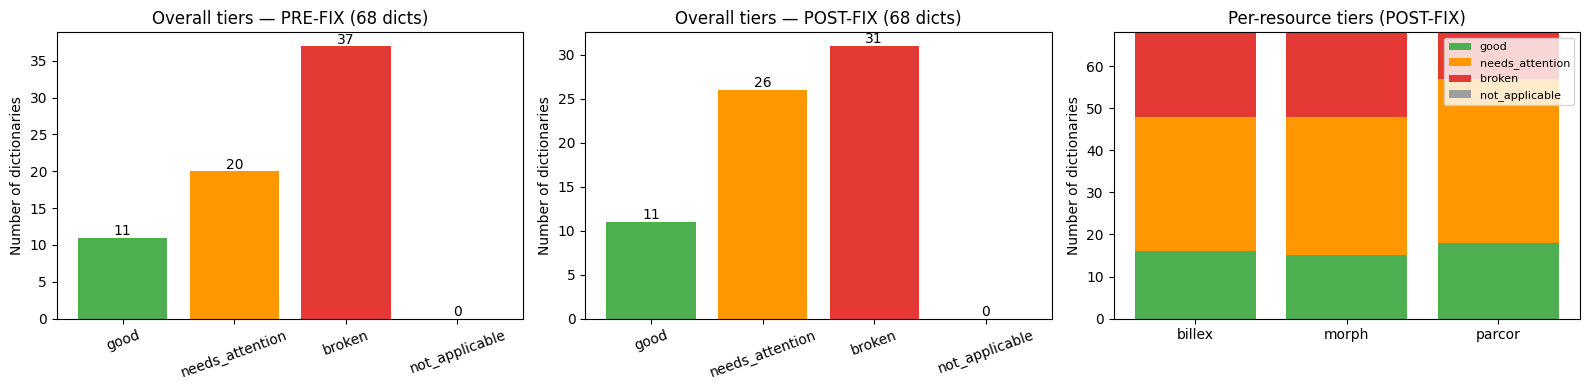

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

tier_colors = {"good": "#4caf50", "needs_attention": "#ff9800",
               "broken": "#e53935", "not_applicable": "#9e9e9e"}
tier_order_plot = ["good", "needs_attention", "broken", "not_applicable"]

# Panel 1: overall pre-fix
pre_counts_plot = metrics_df["overall_tier_prefix"].value_counts().reindex(tier_order_plot, fill_value=0)
axes[0].bar(pre_counts_plot.index, pre_counts_plot.values,
            color=[tier_colors[t] for t in pre_counts_plot.index])
for i, v in enumerate(pre_counts_plot.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontsize=10)
axes[0].set_title(f"Overall tiers — PRE-FIX ({len(metrics_df)} dicts)")
axes[0].set_ylabel("Number of dictionaries")
axes[0].tick_params(axis='x', rotation=20)

# Panel 2: overall post-fix
post_counts_plot = metrics_df["overall_tier_postfix"].value_counts().reindex(tier_order_plot, fill_value=0)
axes[1].bar(post_counts_plot.index, post_counts_plot.values,
            color=[tier_colors[t] for t in post_counts_plot.index])
for i, v in enumerate(post_counts_plot.values):
    axes[1].text(i, v + 0.3, str(v), ha="center", fontsize=10)
axes[1].set_title(f"Overall tiers — POST-FIX ({len(metrics_df)} dicts)")
axes[1].set_ylabel("Number of dictionaries")
axes[1].tick_params(axis='x', rotation=20)

# Panel 3: per-resource tiers post-fix — stacked bar
resources = ["billex", "morph", "parcor"]
per_res = pd.DataFrame({
    r: metrics_df[f"{r}_tier_postfix"].value_counts().reindex(tier_order_plot, fill_value=0)
    for r in resources
}).T
bottom = np.zeros(len(resources))
for tier in tier_order_plot:
    axes[2].bar(per_res.index, per_res[tier].values, bottom=bottom,
                color=tier_colors[tier], label=tier)
    bottom += per_res[tier].values
axes[2].set_title("Per-resource tiers (POST-FIX)")
axes[2].set_ylabel("Number of dictionaries")
axes[2].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(DST_DIR / "_tier_breakdown.png", dpi=120, bbox_inches="tight")
plt.show()

## 13. Aggregate summary

In [14]:
aggregate = {
    "total_dictionaries_audited": len(metrics_df),
    "dicts_with_parcor_source": int(metrics_df["parcor_has_examples_in_source"].sum()),
    "dicts_without_parcor_source": int((~metrics_df["parcor_has_examples_in_source"]).sum()),
    "overall_prefix_good": int((metrics_df["overall_tier_prefix"] == "good").sum()),
    "overall_prefix_needs_attention": int((metrics_df["overall_tier_prefix"] == "needs_attention").sum()),
    "overall_prefix_broken": int((metrics_df["overall_tier_prefix"] == "broken").sum()),
    "overall_postfix_good": int((metrics_df["overall_tier_postfix"] == "good").sum()),
    "overall_postfix_needs_attention": int((metrics_df["overall_tier_postfix"] == "needs_attention").sum()),
    "overall_postfix_broken": int((metrics_df["overall_tier_postfix"] == "broken").sum()),
    "dicts_improved_tier": int(
        (metrics_df["overall_tier_prefix"] != metrics_df["overall_tier_postfix"]).sum()
    ),
    "catastrophic_failures": int(len(cat_df)) if len(cat_df) > 0 else 0,
}

pd.DataFrame([aggregate]).T.rename(columns={0: "value"}).to_csv(DST_DIR / "_aggregate_stats.csv")

for k, v in aggregate.items():
    print(f"  {k:<40} {v:>6}")

print(f"\nAll outputs in: {DST_DIR.resolve()}")

  total_dictionaries_audited                   68
  dicts_with_parcor_source                     68
  dicts_without_parcor_source                   0
  overall_prefix_good                          11
  overall_prefix_needs_attention               20
  overall_prefix_broken                        37
  overall_postfix_good                         11
  overall_postfix_needs_attention              26
  overall_postfix_broken                       31
  dicts_improved_tier                           6
  catastrophic_failures                        21

All outputs in: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKamus\evaluation\sanity_v2


## 14. Drill-down (optional)

Inspect one dictionary in detail.

In [15]:
DRILL_DOWN_DICT_ID = "4"

target = metrics_df[metrics_df["dict_id"] == DRILL_DOWN_DICT_ID]
if len(target) == 0:
    print(f"Dictionary {DRILL_DOWN_DICT_ID} not found.")
else:
    row = target.iloc[0]
    print(f"=== Dict {DRILL_DOWN_DICT_ID} — drill-down ===\n")
    print(f"Direction: {row['direction']} (known: {row['direction_known']})")
    print(f"Source has examples: {row['parcor_has_examples_in_source']} "
          f"(rate {row['parcor_source_example_rate']})")
    print()
    for resource in ["billex", "morph", "parcor"]:
        print(f"--- {resource.upper()} ---")
        print(f"  tier (pre-fix):       {row[f'{resource}_tier_prefix']}")
        print(f"  tier (post-fix):      {row[f'{resource}_tier_postfix']}")
        print(f"  violations (pre):     {row[f'{resource}_violations_prefix'] or '(none)'}")
        print(f"  violations (post):    {row[f'{resource}_violations_postfix'] or '(none)'}")
        print()
    print(f"OVERALL: {row['overall_tier_prefix']}  →  {row['overall_tier_postfix']}")

=== Dict 4 — drill-down ===

Direction: 1 (known: True)
Source has examples: True (rate 0.9598)

--- BILLEX ---
  tier (pre-fix):       needs_attention
  tier (post-fix):      needs_attention
  violations (pre):     billex_too_few_rows
  violations (post):    billex_too_few_rows

--- MORPH ---
  tier (pre-fix):       needs_attention
  tier (post-fix):      needs_attention
  violations (pre):     morph_too_few_rows
  violations (post):    morph_too_few_rows

--- PARCOR ---
  tier (pre-fix):       good
  tier (post-fix):      good
  violations (pre):     (none)
  violations (post):    (none)

OVERALL: needs_attention  →  needs_attention
